In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')

In [ ]:
deliveries=pd.read_csv('deliveries.csv')
matches=pd.read_csv('matches.csv')

matches.head(10)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
5,6,2017,Hyderabad,2017-04-09,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,9,Rashid Khan,"Rajiv Gandhi International Stadium, Uppal",A Deshmukh,NJ Llong,NaN
6,7,2017,Mumbai,2017-04-09,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,N Rana,Wankhede Stadium,Nitin Menon,CK Nandan,NaN
7,8,2017,Indore,2017-04-10,Royal Challengers Bangalore,Kings XI Punjab,Royal Challengers Bangalore,bat,normal,0,Kings XI Punjab,0,8,AR Patel,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
8,9,2017,Pune,2017-04-11,Delhi Daredevils,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Delhi Daredevils,97,0,SV Samson,Maharashtra Cricket Association Stadium,AY Dandekar,S Ravi,NaN
9,10,2017,Mumbai,2017-04-12,Sunrisers Hyderabad,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,JJ Bumrah,Wankhede Stadium,Nitin Menon,CK Nandan,NaN


In [ ]:
#data cleaning
matches.info()
matches.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               756 non-null    int64
 1   season           756 non-null    int64
 2   city             749 non-null    str  
 3   date             756 non-null    str  
 4   team1            756 non-null    str  
 5   team2            756 non-null    str  
 6   toss_winner      756 non-null    str  
 7   toss_decision    756 non-null    str  
 8   result           756 non-null    str  
 9   dl_applied       756 non-null    int64
 10  winner           752 non-null    str  
 11  win_by_runs      756 non-null    int64
 12  win_by_wickets   756 non-null    int64
 13  player_of_match  752 non-null    str  
 14  venue            756 non-null    str  
 15  umpire1          754 non-null    str  
 16  umpire2          754 non-null    str  
 17  umpire3          119 non-null    str  
dtypes: int64(5), str(13)


id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64

In [ ]:
matches['city'].fillna("Unknown", inplace=True)

C:\Users\priya\AppData\Local\Temp\ipykernel_5372\2749084892.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  matches['city'].fillna("Unknown", inplace=True)


0          Hyderabad
1               Pune
2             Rajkot
3             Indore
4          Bangalore
           ...      
751           Mumbai
752          Chennai
753    Visakhapatnam
754    Visakhapatnam
755        Hyderabad
Name: city, Length: 756, dtype: str

In [ ]:
# 1-Match won by the maximum margin of runs

max_runs = matches['win_by_runs'].max()
max_run_match = matches[matches['win_by_runs'] == max_runs]

max_run_match[['season','team1','team2','winner','win_by_runs']]

,season,team1,team2,winner,win_by_runs
43,2017,Mumbai Indians,Delhi Daredevils,Mumbai Indians,146


### insights:-
 Match id no. 43 matches bwtween Mumbai Indians and Delhi Daredevils and Mumbai Indians win by Maximum margin of 143 runs 

In [ ]:
# 2- Match won by maximum wickets

max_wickets = matches['win_by_wickets'].max()
matches[matches['win_by_wickets'] == max_wickets][['season','team1','team2','winner','win_by_wickets']]



,season,team1,team2,winner,win_by_wickets
2,2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,10
34,2017,Delhi Daredevils,Kings XI Punjab,Kings XI Punjab,10
71,2008,Mumbai Indians,Deccan Chargers,Deccan Chargers,10
119,2009,Kings XI Punjab,Delhi Daredevils,Delhi Daredevils,10
183,2010,Rajasthan Royals,Royal Challengers Bangalore,Royal Challengers Bangalore,10
298,2011,Mumbai Indians,Rajasthan Royals,Rajasthan Royals,10
376,2012,Rajasthan Royals,Mumbai Indians,Mumbai Indians,10
390,2013,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,10
542,2015,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,10
590,2016,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,10


##### INSIGHTS :- 
   There are total 11 matches won by maximum wickets . Match id-no 2,34,71,119,183,298,376,390,542,590,683.

In [ ]:
# 3.Match won by minimum margin of runs

min_runs = matches[matches['win_by_runs'] > 0]['win_by_runs'].min()
matches[matches['win_by_runs'] == min_runs][['season','winner','win_by_runs']]

,season,winner,win_by_runs
58,2017,Mumbai Indians,1
105,2008,Kings XI Punjab,1
163,2009,Kings XI Punjab,1
344,2012,Delhi Daredevils,1
350,2012,Mumbai Indians,1
518,2015,Chennai Super Kings,1
598,2016,Gujarat Lions,1
614,2016,Royal Challengers Bangalore,1
734,2019,Royal Challengers Bangalore,1
755,2019,Mumbai Indians,1


#### INSIGHTS :-
There are 10 matches which are won by very less margine . Matches Id_no- 58,105,163,344,350,518,598,614,734,755

In [ ]:
# 4.Match won by minimum wickets

min_wickets = matches[matches['win_by_wickets'] > 0]['win_by_wickets'].min()
matches[matches['win_by_wickets'] == min_wickets][['season','winner','win_by_wickets']]

,season,winner,win_by_wickets
559,2015,Kolkata Knight Riders,1
636,2018,Chennai Super Kings,1
642,2018,Sunrisers Hyderabad,1


#### INSIGHTS :-
There are three matches which are won by minimum wickets . Matches Id_no- 559,636,642

In [ ]:
#5.Matches where D/L method was and wasn't applied

matches['dl_applied'].value_counts()



dl_applied
0    737
1     19
Name: count, dtype: int64

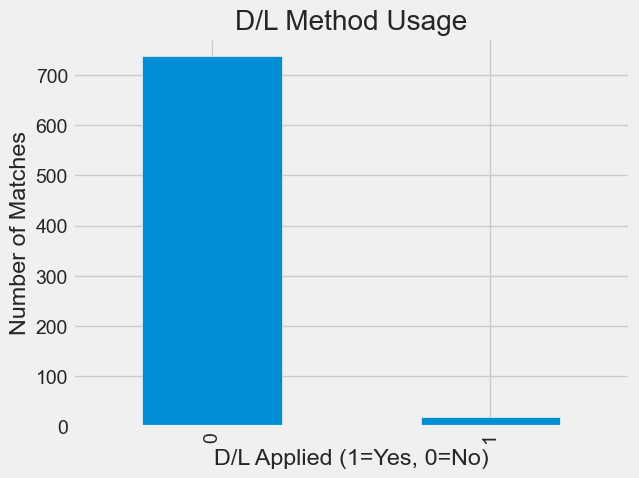

In [ ]:
#graph for D/L method

matches['dl_applied'].value_counts().plot(kind='bar')
plt.title("D/L Method Usage")
plt.xlabel("D/L Applied (1=Yes, 0=No)")
plt.ylabel("Number of Matches")
plt.show()

#### INSIGHTS :-

The majority of matches were played without using the D/L method.
D/L method was applied only in rain-affected matches, which are comparatively fewer.

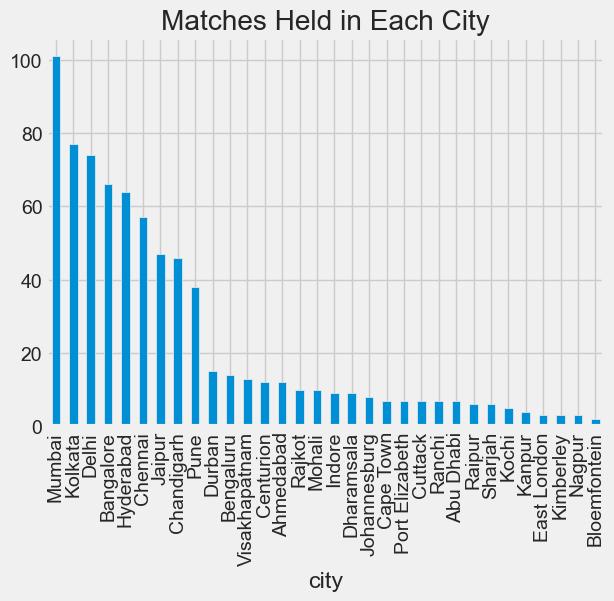

In [ ]:
# 6.No. of matches held in each city
city_matches = matches['city'].value_counts()
city_matches.plot(kind='bar')
plt.title("Matches Held in Each City")
plt.xticks(rotation=90)
plt.show()

#### INSIGHTS :-
 Most matches are held in mumbai city .

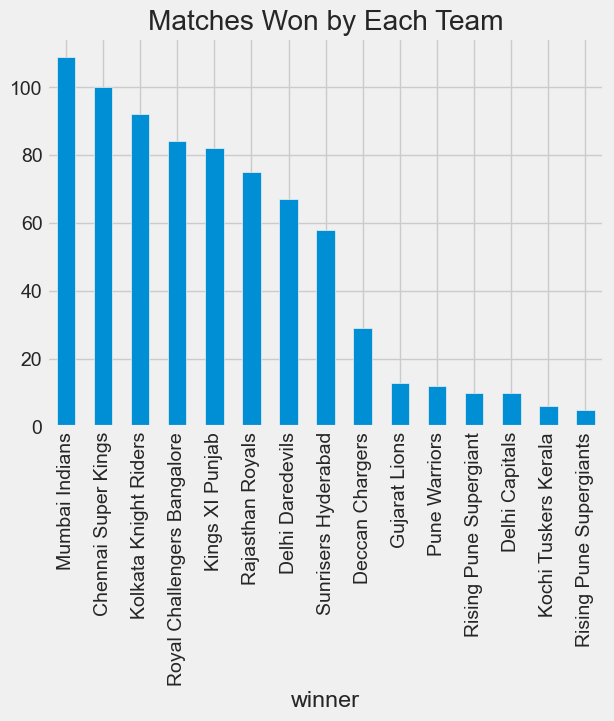

In [ ]:
# 7.No. of matches won by each team

team_wins = matches['winner'].value_counts()
team_wins.plot(kind='bar')
plt.title("Matches Won by Each Team")
plt.xticks(rotation=90)
plt.show()

#### INSIGHTS :-
                Most matches are win by mumbai indians , Team with highest wins is most successful franchise.

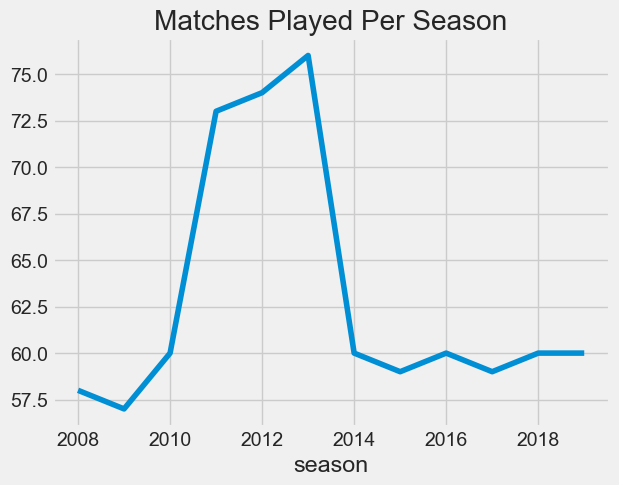

In [ ]:
# 8.No. of matches held every season
season_matches = matches['season'].value_counts().sort_index()
season_matches.plot(kind='line')
plt.title("Matches Played Per Season")
plt.show()

#### INSIGHTS :-
               The number of matches played per season increased over time, indicating the growth and popularity of the IPL tournament. As more teams joined the league, the schedule expanded to include more matches.                                                            

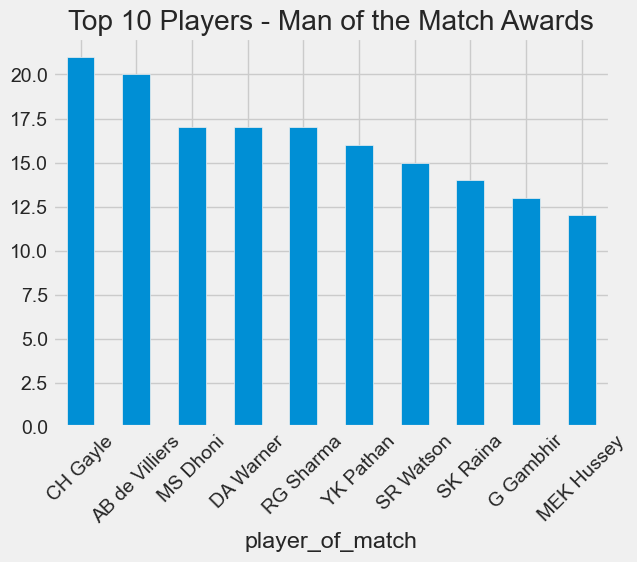

In [ ]:
# 9.Top 10 players based on Man of the Match awards
top_mom = matches['player_of_match'].value_counts().head(10)
top_mom.plot(kind='bar')
plt.title("Top 10 Players - Man of the Match Awards")
plt.xticks(rotation=45)
plt.show()

#### INSIGHTS :-
                 The players shown in the graph have received the highest number of Man of the Match awards, indicating their consistent match-winning performances across multiple IPL seasons

In [ ]:
# 10. Does winning the toss mean winning the match?
toss_match_win = matches[matches['toss_winner'] == matches['winner']]
percentage = (len(toss_match_win) / len(matches)) * 100

print("Percentage of matches where toss winner also won match:", percentage)

Percentage of matches where toss winner also won match: 51.98412698412699


#### INSIGHTS :-
               By the above data wining toss has slightly advantage but Toss doesn't strongly decide match outcomes

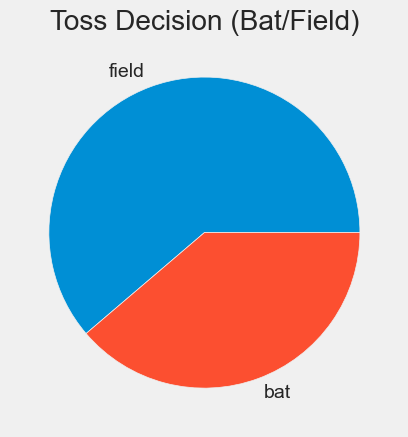

In [ ]:
# 11.Decision taken by captains after winning toss
matches['toss_decision'].value_counts().plot(kind='pie')
plt.title("Toss Decision (Bat/Field)")
plt.show()

season
2008    2
2009    3
2011    3
2014    1
2015    2
2016    4
2017    1
2018    3
Name: count, dtype: int64


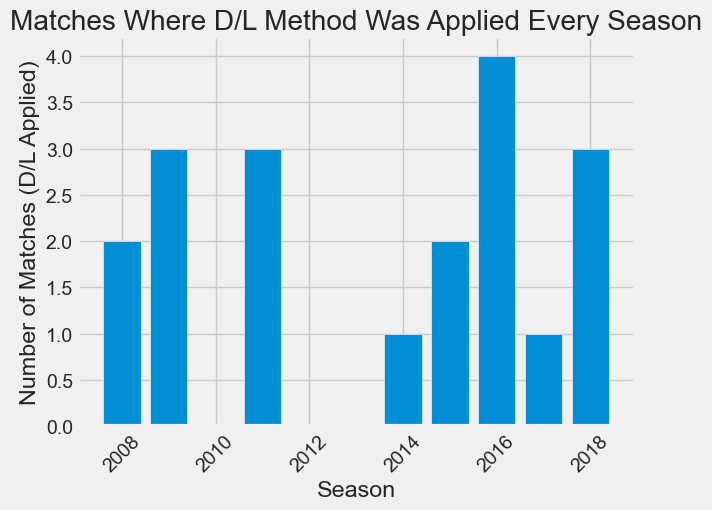

In [ ]:
# 12.Matches where D/L method applied every season
dl_matches = matches[matches['dl_applied'] == 1]
dl_season = dl_matches['season'].value_counts().sort_index()

print(dl_season)

plt.figure()
plt.bar(dl_season.index, dl_season.values)

plt.title("Matches Where D/L Method Was Applied Every Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches (D/L Applied)")

plt.xticks(rotation=45)

plt.show()

result
normal       743
tie            9
no result      4
Name: count, dtype: int64


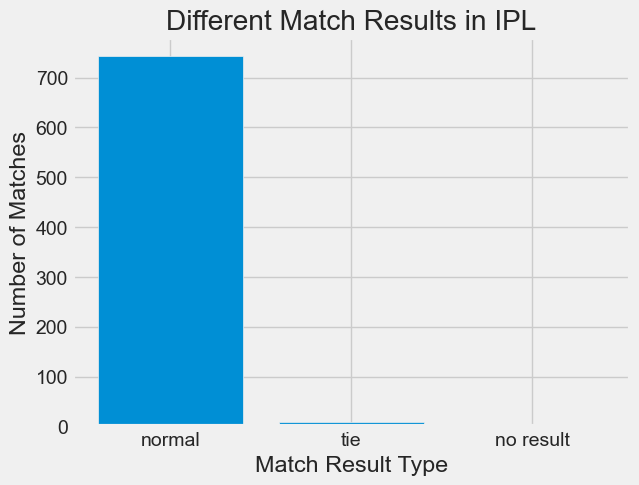

In [ ]:
# 13. Different match results
matches['result'].value_counts()

result_counts = matches['result'].value_counts()

print(result_counts)

# Plot bar graph
plt.figure()
plt.bar(result_counts.index, result_counts.values)

plt.title("Different Match Results in IPL")
plt.xlabel("Match Result Type")
plt.ylabel("Number of Matches")

plt.show()

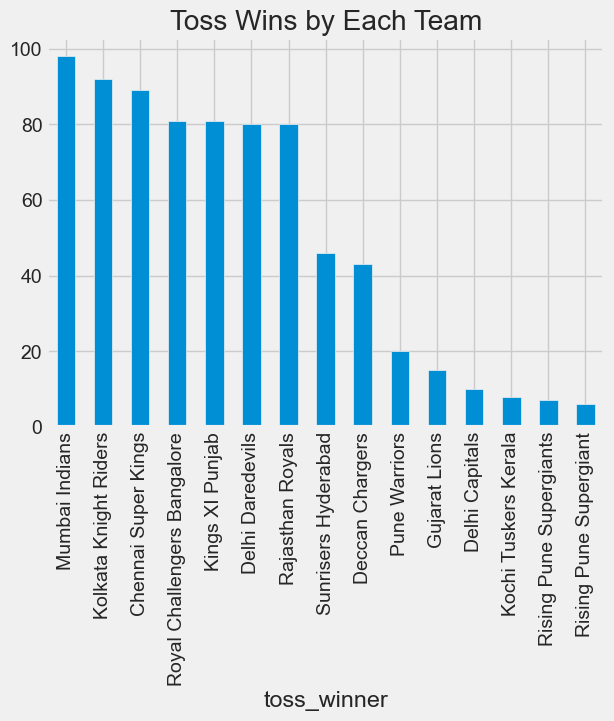

In [ ]:
# 14.How many times did each team win the toss?

toss_wins = matches['toss_winner'].value_counts()
toss_wins.plot(kind='bar')
plt.title("Toss Wins by Each Team")
plt.xticks(rotation=90)
plt.show()

#### INSIGHTS :-
                This shows the Tosses won by the each teams . Most of the tosses won by the mumbai indians 

In [ ]:
# 15.Best venue for defending and chasing 

defending = matches[matches['win_by_runs'] > 0]
chasing = matches[matches['win_by_wickets'] > 0]

best_defend_venue = defending['venue'].value_counts().head(5)
best_chase_venue = chasing['venue'].value_counts().head(5)

print("Best Venues for Defending:")
print(best_defend_venue)

print("\nBest Venues for Chasing:")
print(best_chase_venue)

Best Venues for Defending:
venue
Wankhede Stadium                   35
Feroz Shah Kotla                   33
Eden Gardens                       32
M Chinnaswamy Stadium              30
MA Chidambaram Stadium, Chepauk    30
Name: count, dtype: int64

Best Venues for Chasing:
venue
Eden Gardens                                 45
M Chinnaswamy Stadium                        40
Wankhede Stadium                             37
Feroz Shah Kotla                             33
Rajiv Gandhi International Stadium, Uppal    32
Name: count, dtype: int64


In [ ]:
# 16. Best defending and chasing teams

best_defend_team = defending['winner'].value_counts().head(5)
best_chase_team = chasing['winner'].value_counts().head(5)

print("Best Defending Teams:")
print(best_defend_team)

print("\nBest Chasing Teams:")
print(best_chase_team)

Best Defending Teams:
winner
Mumbai Indians                 57
Chennai Super Kings            52
Kings XI Punjab                38
Kolkata Knight Riders          36
Royal Challengers Bangalore    35
Name: count, dtype: int64

Best Chasing Teams:
winner
Kolkata Knight Riders          56
Mumbai Indians                 50
Royal Challengers Bangalore    48
Chennai Super Kings            48
Rajasthan Royals               46
Name: count, dtype: int64


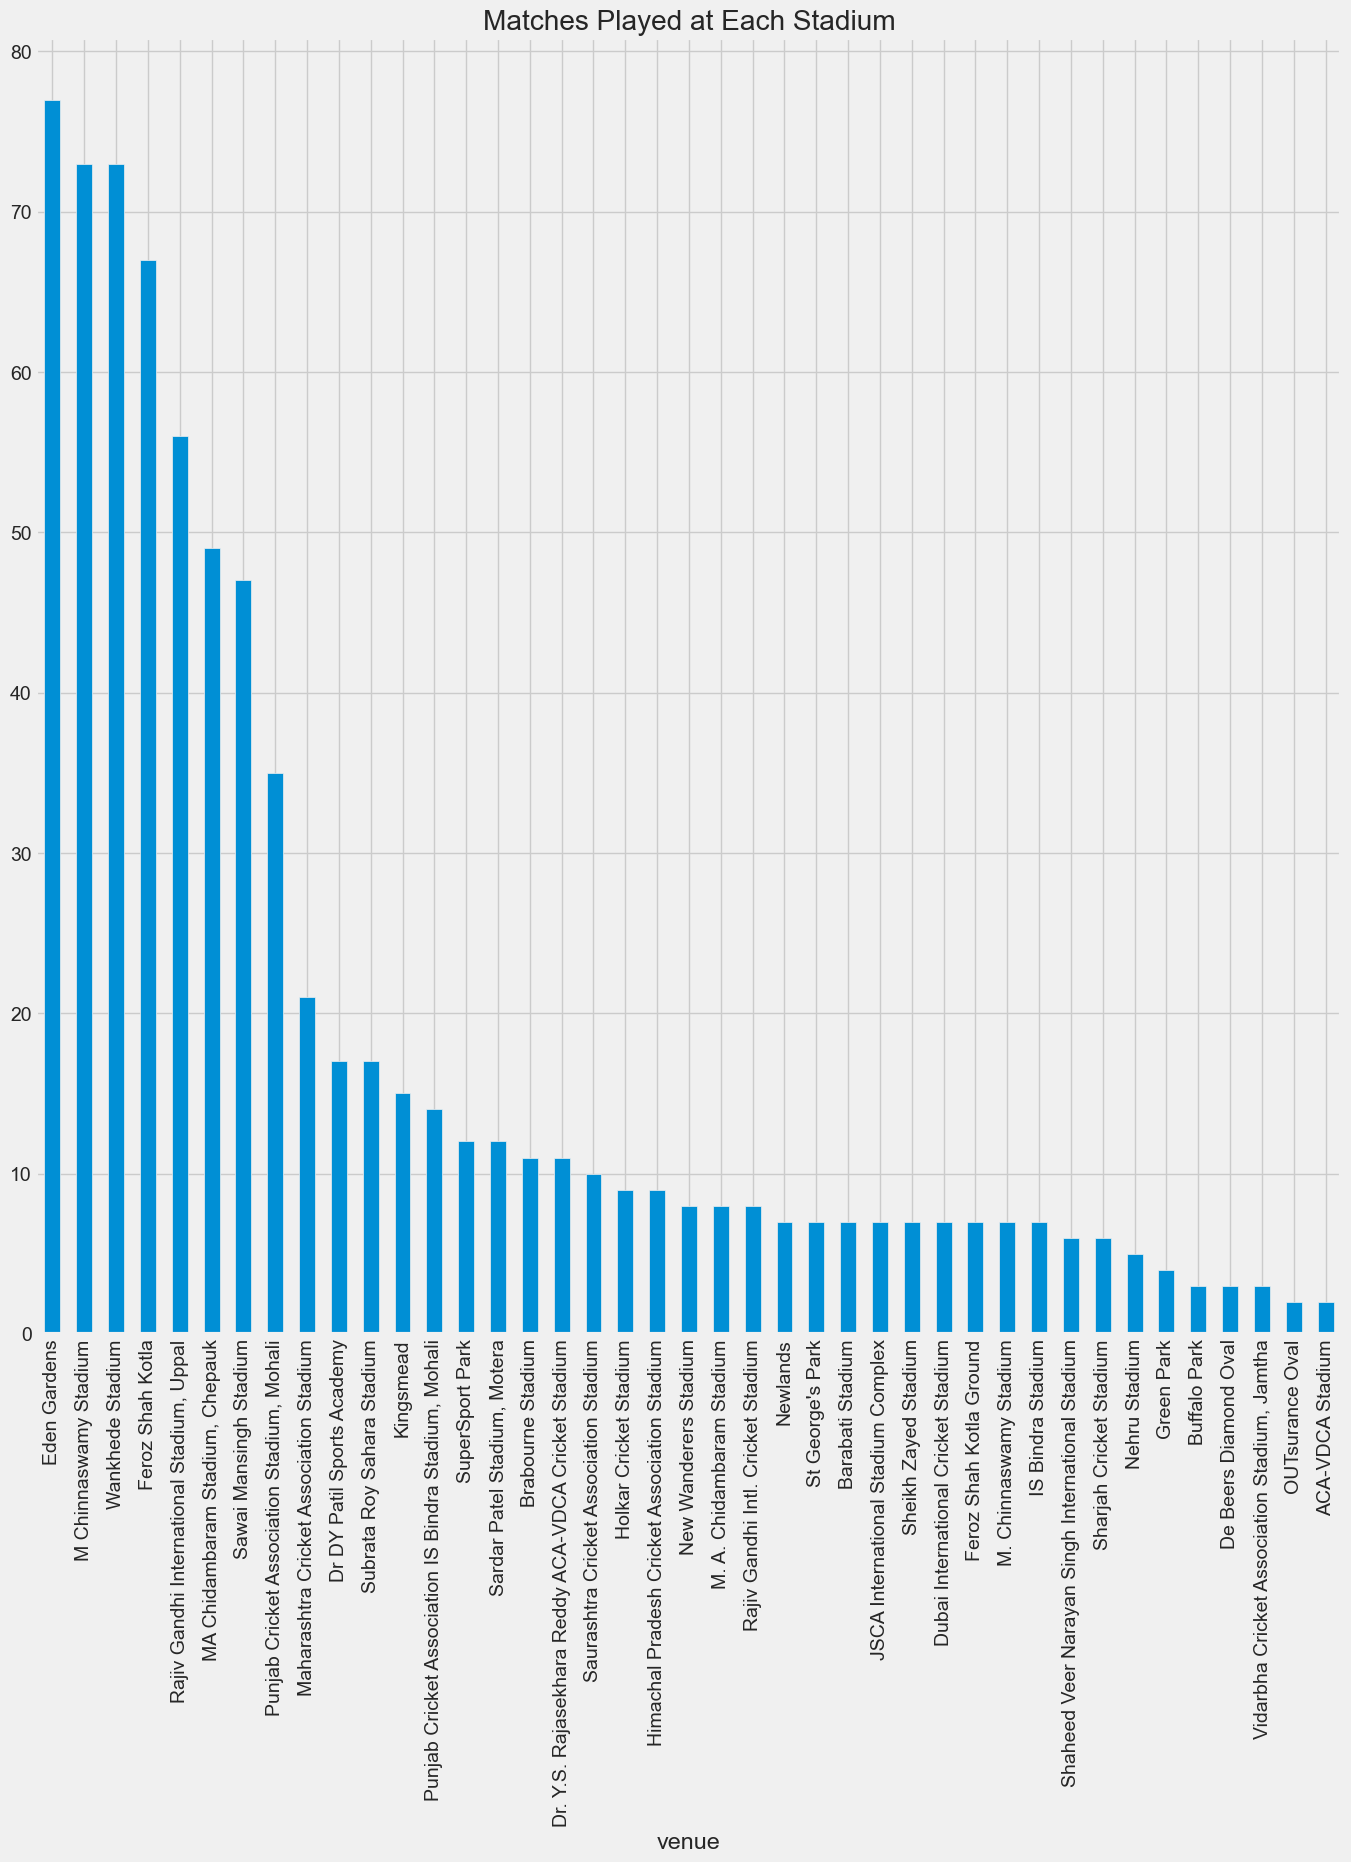

In [ ]:
# 17.Matches played in different stadiums
plt.figure(figsize=(15,16))
venue_matches = matches['venue'].value_counts()
venue_matches.plot(kind='bar')
plt.title("Matches Played at Each Stadium")
plt.xticks(rotation=90)
plt.show()

### INSIGHTS :-
 __1__: most matches are won by mumbai indians 

 __2__:most matches are played at Eden gardens 

 __3__: - Best Defending Team -Mumbai Indians

        - Best Chasing Team-Kolkata Knight Riders

 __4__:  - Best venue for defending - Wankhede stadium
 
         - Best venue for chasing -Eden gardens  

__5__: Most IPL matches end with a normal result, while tie and no result matches occur very rarely. This indicates that the majority of matches are completed successfully without interruptions. 

__6__:  Most of the times captain decided to field first after winning the Toss 

__7__:   Most matches are win by mumbai indians , Most wins means most successful franchise.  

__8__:Most matches are held in mumbai city .

__9__:most Tosses are won by the mumbai indians 